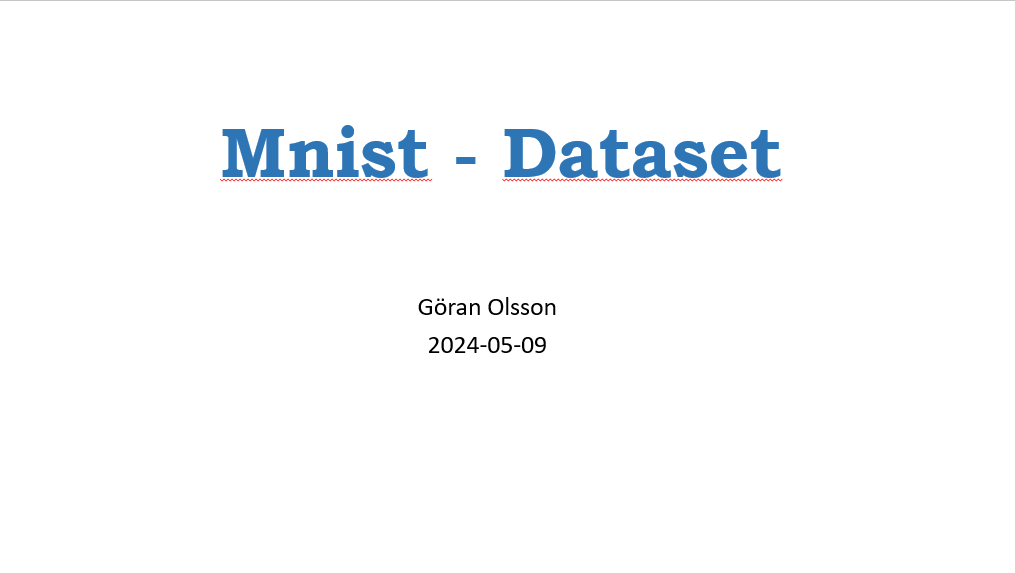

https://gosolna-commits.github.io/yh-kunskapskontroll-ai-index/

https://github.com/gosolna-commits/YH-Kunskapskontroll-AI
Göran_kunskapskontroll_AI.ipynb
Mnist - funderingar.pdf
Göran_kunskapskontroll_AI_frågorna.ipynb

https://github.com/gosolna-commits/mnist-pics
mnist-pics.py

https://github.com/gosolna-commits/mnist-mlp-cnn
app.py
mlp_model.pkl
cnn_model.keras

https://github.com/gosolna-commits/mnist-cnn
Göran_ML_CNN_sparad.py

https://github.com/gosolna-commits/mnist-LogReg
Göran_ML_LogReg.py


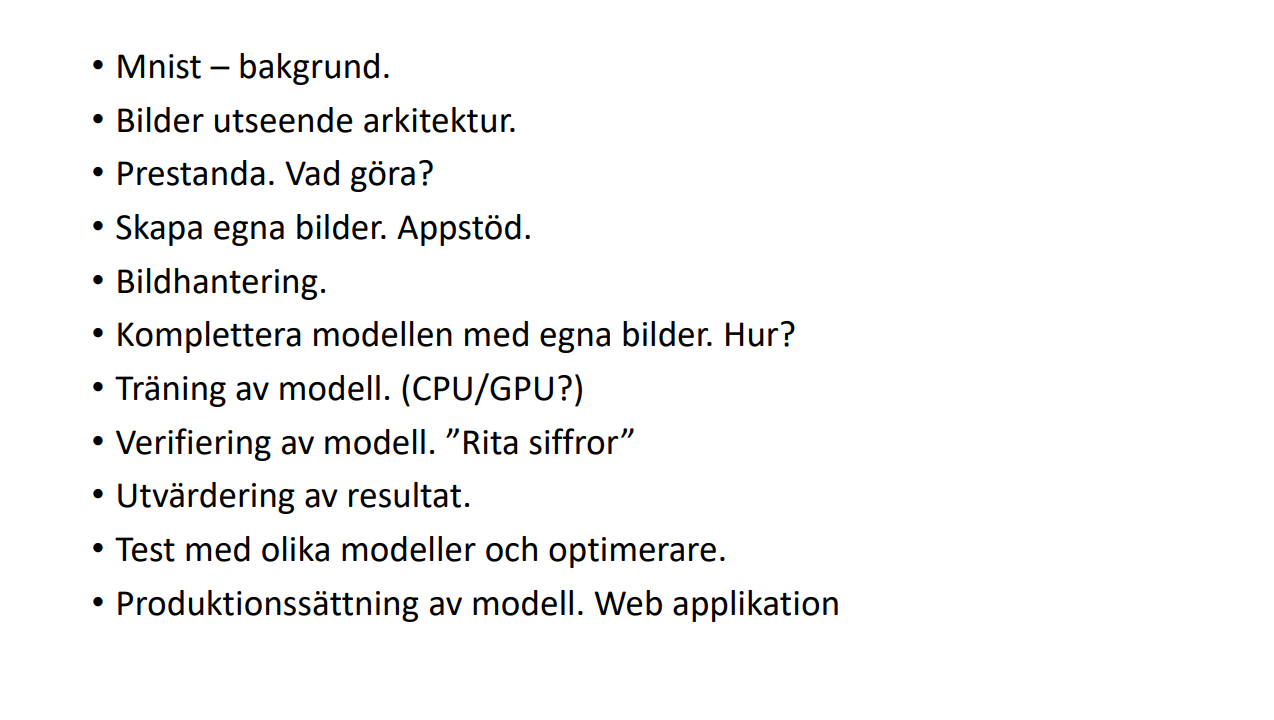

# ML - projekt

- 1.  Datainsamling
- 2.  Data förberedelse
- 3.  Dela upp data
- 4.  Feature engineering   
- 5.  Välj modell
- 6.  Träna modell
- 7.  Utvärdera modell
- 8.  Tuning ocg förbättring     
- 9.  Deployment
- 10. Övervakning

# Inledning

MNIST är ett dataset med 70.000 biler på siffror 0-9.
Datasetet är uppdelat i träning och test biler, 60.000 resp. 10.000.
Varje bild är märkt med siffra som stämmer överens med bilden.
Det är enkelt och välstrukturerat och bra för träning och undervisning.
Användningsområde.
- Träning och test av klassificeringsmodeller.
- Introduktion till neurala nätverk
- Optimering och utvärdering av prestationsförmåga.

# 1. Datainsamling

### Förklaring av datainsamling
Denna kod laddar in MNIST-datasetet som innehåller handskrivna siffror från 0–9. Datasetet används ofta inom maskininlärning för bildklassificering.

Koden delar upp datan i:
- träningsdata (`X_train`, `y_train`)
- testdata (`X_test`, `y_test`)

Syftet är att träna modellen på träningsdata och sedan utvärdera modellen på testdata som modellen inte sett tidigare.

In [70]:
# Importera python  bibliotek
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D



In [71]:
# ======================================================
# LADDA MNIST
# ======================================================
#from sklearn.datasets import fetch_openml
#from sklearn.model_selection import train_test_split

# Ladda MNIST
# mnist = fetch_openml('mnist_784', version=1)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Data och labels
#X = mnist.data.to_numpy()
#y = mnist.target.astype(int)

X = x_train
y = y_train

# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Andra split:
# Train / Validation
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (36000, 28, 28)
Validation: (12000, 28, 28)
Test: (12000, 28, 28)


## EDA

1. Datasetstorlek
2. Klassfördelning
3. Visualisering av exempelbilder
4. Pixelintensitet
5. Felklassificeringar



# 2. Dataförberedelse

### MNIST bilder exempel

Bild egenskaper
* 28x28 pixlar
* Gråskala
* Normaliserad (0–1)

img = img.resize((28,28)).convert("L")
img = np.array(img) / 255.0
img = 1 - img   # ofta behövs invertering

In [72]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

print(type(x_train))
print(type(y_train))

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


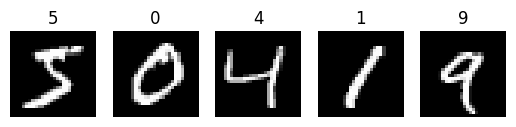

In [73]:
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

De första testerna visar på bristfälligt resultat. Skapade egna bilder för att komplettera. Kanske inte nödvändigt.
Lokal app. Finns även som streamlit länk.
https://mnist-pics-s8ciztwncgezrbartfdkuu.streamlit.app/
Brist i den just nu. Filerna sparas i unix. Måste kompletteras om man enkelt vill få ner bilderna lokalt.

### Förklaring av egna bilder
Här används egna skapade bilder för att komplettera MNIST-datasetet. Detta kan förbättra modellens förmåga att känna igen variationer som inte finns i originaldatan.

Egna bilder kan bidra till:
- bättre generalisering
- robustare modell
- högre träffsäkerhet på verkliga handskrivna siffror

### App för att skapa MNIST anpassade bilder.

In [16]:
import tkinter as tk
from PIL import Image, ImageDraw
import os

# Create dataset folders
for i in range(10):
    os.makedirs(f"data/{i}", exist_ok=True)

class MNISTDrawer:
    def __init__(self, root):
        self.root = root
        self.root.title("MNIST Drawing App")

        self.canvas_size = 280  # large canvas for drawing
        self.image_size = 28    # MNIST size

        self.canvas = tk.Canvas(root, width=self.canvas_size, height=self.canvas_size, bg="black")
        self.canvas.pack()

        self.canvas.bind("<B1-Motion>", self.draw)

        self.button_frame = tk.Frame(root)
        self.button_frame.pack()

        for i in range(10):
            btn = tk.Button(self.button_frame, text=str(i), command=lambda i=i: self.save(i))
            btn.grid(row=0, column=i)

        self.clear_btn = tk.Button(root, text="Clear", command=self.clear)
        self.clear_btn.pack()

        # PIL image for saving
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def draw(self, event):
        x, y = event.x, event.y
        r = 8

        self.canvas.create_oval(x-r, y-r, x+r, y+r, fill="white", outline="white")
        self.draw_image.ellipse([x-r, y-r, x+r, y+r], fill=255)

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self.draw_image = ImageDraw.Draw(self.image)

    def save(self, label):
        # Resize to MNIST size
        img = self.image.resize((self.image_size, self.image_size))

        # Save image
        count = len(os.listdir(f"data/{label}"))
        filename = f"data/{label}/{count}.png"
        img.save(filename)

        print(f"Saved {filename}")
        self.clear()

if __name__ == "__main__":
    root = tk.Tk()
    app = MNISTDrawer(root)
    root.mainloop()

Saved data/3/12.png


### Kod för import av kundspecifika bilder

### Bildbehandling

- Läs in bild
- Ändra storlek till 28×28
- Invertera färger (vid behov)
- Konvertera till numpy-array
- Flatten till 784 features
- Normalisera pixelvärden
- Lägg till i dataset

img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28,28))

img = 255 - img

img = img.reshape(784)

img = img / 255.0

In [1]:
# Pillow bibliotek
from PIL import Image

In [2]:
# CUSTOM PICS

import os

import numpy as np


data = []
labels = []

path = ".\data"

for label in range(10):
    folder = os.path.join(path, str(label))
    
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        
        # Open image
        img = Image.open(img_path).convert('L')  # grayscale
        
        # Resize to 28x28
        #img = img.resize((28, 28))
        
        # Invert colors (IMPORTANT for MNIST!)
        # img = 255 - img
               
        data.append(img)
        labels.append(label)

# Convert to numpy
X_custom = np.array(data)
y_custom = np.array(labels)

X_custom = X_custom.reshape(-1, 784)

# Normalize
X_custom = X_custom / 255.0

print(X_custom.shape)  # (num_images, 28, 28)
print(X_custom.min())
print(X_custom.max())

(115, 784)
0.0
1.0


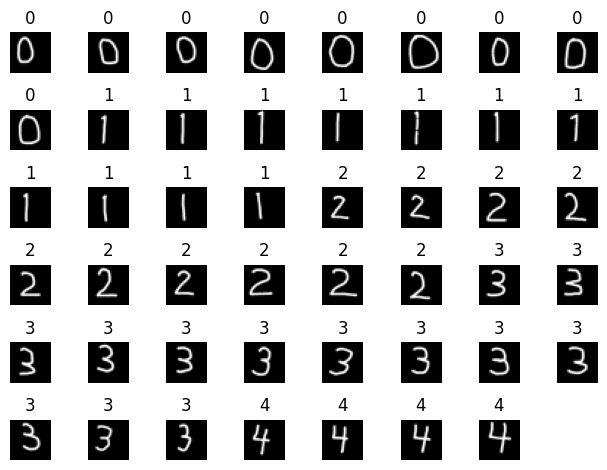

In [3]:
import matplotlib.pyplot as plt

for i in range(1, 48):

    plt.subplot(6, 8, i)

    plt.imshow(X_custom[i].reshape(28,28), cmap='gray')

    plt.title(y_custom[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

### Förklaring av normalisering
Normalisering innebär att pixelvärden skalas om från intervallet 0–255 till 0–1.

Detta görs eftersom:
- modellen tränar stabilare
- gradient descent fungerar bättre
- träningen blir snabbare

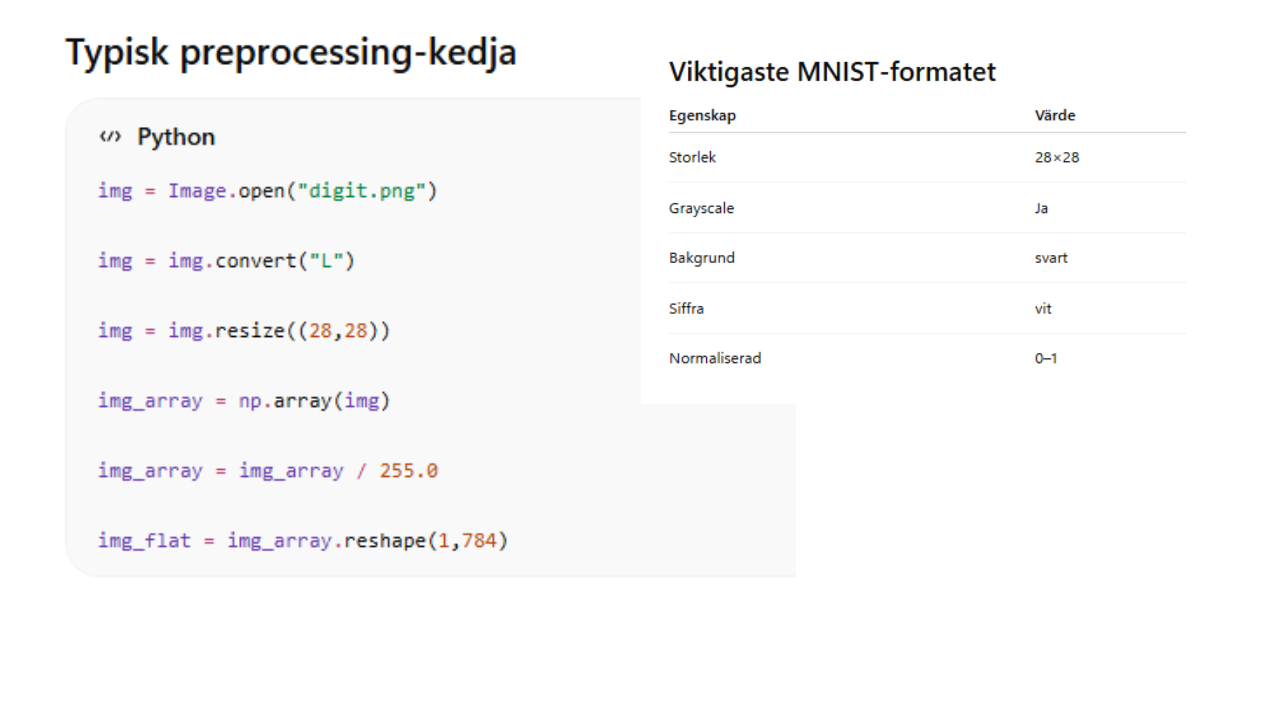

### Skapar X_combine och y_combine med både MNIST och egna bilder.

In [4]:
# import katalog
print(os.getcwd())

G:\Min enhet\AI_prov\mnist-start


In [7]:
from tensorflow.keras.datasets import mnist
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# -----------------------------------
# Load MNIST
# -----------------------------------

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Flatten
X_train_mnist = X_train_mnist.reshape(-1, 784)
X_test_mnist = X_test_mnist.reshape(-1, 784)

# Normalize ONCE!
X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

X_combine = np.concatenate((X_train_mnist, X_custom), axis=0)
y_combine = np.concatenate((y_train_mnist, y_custom), axis=0)

print(X_combine.shape)
print(y_combine.shape)

# -----------------------------------
# Model
# -----------------------------------

model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_combine, y_combine)

# Predict
y_pred_mnist = model.predict(X_test_mnist)

# Accuracy
# acc = accuracy_score(y_test_mnist, y_pred_mnist)

acc = accuracy_score(X_test_mnist, y_test_mnist)

print("Accuracy:", acc)




(60115, 784)
(60115,)
Accuracy: 0.9743


In [23]:
score = model.score(X_test_mnist, y_test_mnist)

print(score)

0.9743


In [8]:
print(X_train_mnist.min(), X_train_mnist.max())
print(X_test_mnist.min(), X_test_mnist.max())

0.0 1.0
0.0 1.0


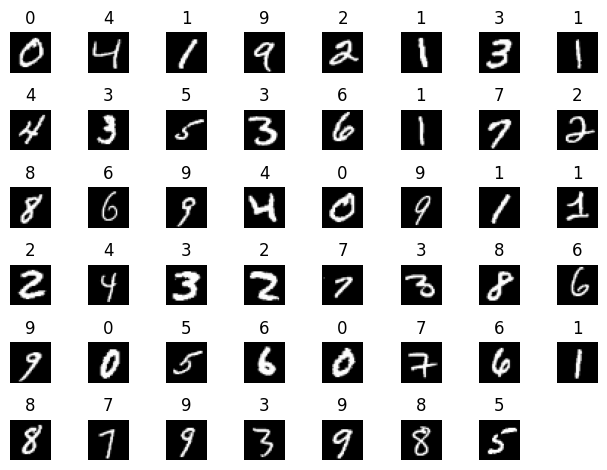

In [9]:
import matplotlib.pyplot as plt

for i in range(1, 48):

    plt.subplot(6, 8, i)

    plt.imshow(X_train_mnist[i].reshape(28,28), cmap='gray')

    plt.title(y_train_mnist[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
print('X_test')
print(X_test_mnist.shape)  # (num_images, 28, 28)
print(X_test_mnist.min())
print(X_test_mnist.max())
print('X_train')
print(X_train_mnist.shape)  # (num_images, 28, 28)
print(X_train_mnist.min())
print(X_train_mnist.max())
print('X_custom')
print(X_custom.shape)  # (num_images, 28, 28)
print(X_custom.min())
print(X_custom.max())



X_test
(10000, 784)
0.0
1.0
X_train
(60000, 784)
0.0
1.0
X_custom
(115, 784)
0.0
1.0


In [12]:
print(y_test_mnist.shape)
print(y_pred_mnist.shape)

print(X_combine.shape)
print(y_combine.shape)

y_pred = model.predict(X_test_mnist)

print(y_pred_mnist[:20])
print(y_test_mnist[:20])


(10000,)
(10000,)
(60115, 784)
(60115,)
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [14]:
train_acc = model.score(X_combine, y_combine)
test_acc = model.score(X_test_mnist, y_test_mnist)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 1.0
Test accuracy: 0.9743


In [17]:
pred_labels = model.predict(X_test_mnist)

wrong = np.where(pred_labels != y_test_mnist)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 257


In [18]:
#pred_labels = np.argmax(pred, axis=1)

errors = np.where(pred_labels != y_test_mnist)[0]

# count errors per digit
counts = {i: 0 for i in range(10)}

for i in errors:
    counts[y_test_mnist[i]] += 1

print("Errors per digit:", counts)

# worst digit
worst_digit = max(counts, key=counts.get)
print("Worst digit:", worst_digit)

Errors per digit: {0: 8, 1: 13, 2: 31, 3: 31, 4: 25, 5: 21, 6: 17, 7: 32, 8: 34, 9: 45}
Worst digit: 9


In [20]:
combine_acc = model.score(X_combine, y_combine)

print("Combine accuracy:", combine_acc)

model.score(X_test_mnist, y_test_mnist)

Combine accuracy: 1.0


0.9743

In [21]:
print('X_train_mnist')
print(X_train_mnist.shape)
print(y_train_mnist.shape)
print('X_test_mnist')
print(X_test_mnist.shape)
print(y_test_mnist.shape)
print('X_custom')
print(X_custom.shape)
print(y_custom.shape)
print('X_combine')
print(X_combine.shape)
print(y_combine.shape)

print()
print(y_combine.dtype)
print(np.unique(y_combine))


X_train_mnist
(60000, 784)
(60000,)
X_test_mnist
(10000, 784)
(10000,)
X_custom
(115, 784)
(115,)
X_combine
(60115, 784)
(60115,)

int64
[0 1 2 3 4 5 6 7 8 9]


# 3. Dela upp data

### Förklaring av train/test-split
Datan delas upp i träningsdata och testdata.

- Träningsdata används för att lära modellen.
- Testdata används för att kontrollera hur bra modellen fungerar på ny data.

Detta är viktigt för att undvika överanpassning (overfitting).

In [24]:
# -----------------------------------
# Första split:
# Train + Validation / Test
# -----------------------------------

from sklearn.model_selection import train_test_split


X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_combine,
    y_combine,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Storlekar
# -----------------------------------

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_mnist.shape)


Training: (48092, 784)
Validation: (12023, 784)
Test: (10000, 784)


In [26]:
print(y_test_mnist.shape)  # (num_images, 28, 28)
print(y_test_mnist.min())
print(y_test_mnist.max())

print(y_train_mnist.shape)  # (num_images, 28, 28)
print(y_train_mnist.min())
print(y_train_mnist.max())

(10000,)
0
9
(60000,)
0
9


In [27]:
print(model.score(X_test_mnist, y_test_mnist))

0.9743


In [28]:
print(X_train_mnist.min(), X_train_mnist.max())
print(X_test_mnist.min(), X_test_mnist.max())
print(X_custom.min(), X_custom.max())

0.0 1.0
0.0 1.0
0.0 1.0


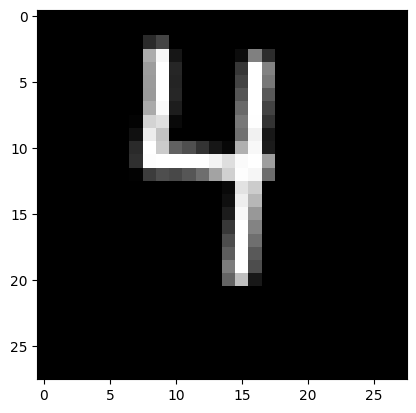

In [54]:
import matplotlib.pyplot as plt

plt.imshow(X_custom[52].reshape(28,28), cmap="gray")
plt.show()

In [30]:
print(X_custom.min())
print(X_custom.max())


0.0
1.0


In [35]:
model.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [37]:
val_acc = model.score(X_val, y_val)

print("Validation accuracy:", val_acc)

Validation accuracy: 0.9700573900024952


In [45]:
wrong = np.where(y_pred_mnist != y_test_mnist)[0]

print("Wrong:", len(wrong))

Wrong: 257


In [46]:
print(X_test_mnist.shape)
print(y_test_mnist.shape)

print(y_pred_mnist.shape)

print(model.score(X_test_mnist, y_test_mnist))

(10000, 784)
(10000,)
(10000,)
0.97


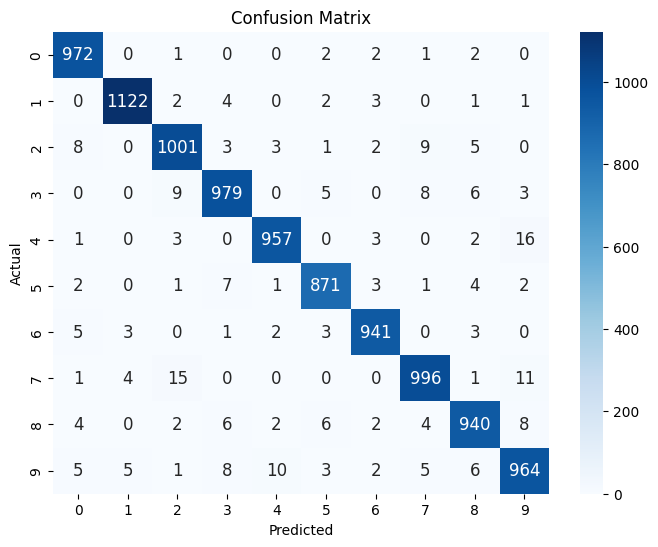

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_mnist, y_pred_mnist)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",  annot_kws={"size": 12})

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

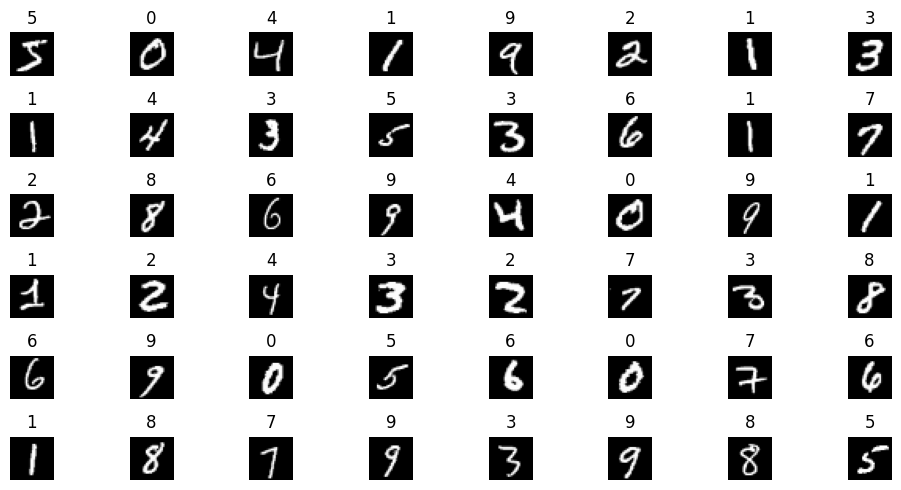

In [44]:
#plt.figure(figsize=(10,8))
plt.figure(figsize=(10,5))

for i in range(48):

    plt.subplot(6, 8, i+1)

    plt.imshow(
        X_train_mnist[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(y_train_mnist[i])

    plt.axis('off')

plt.tight_layout()
plt.show()

### Tabellerna

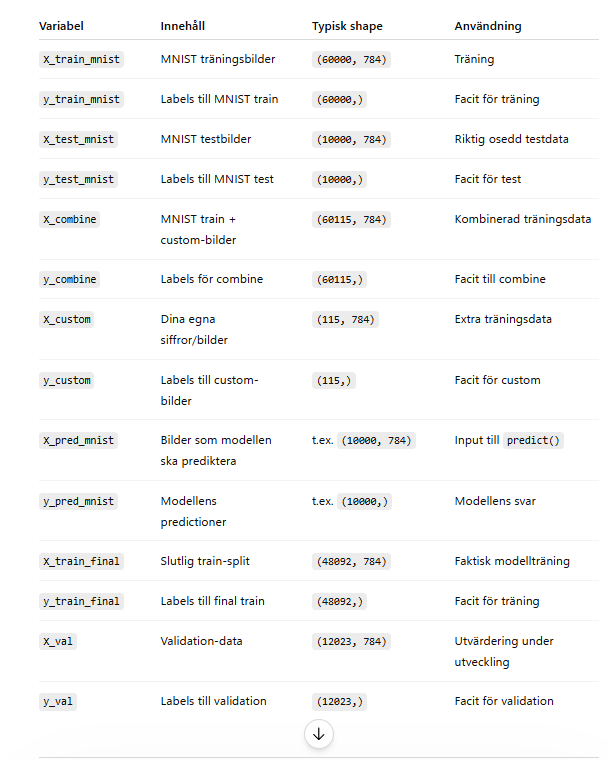

# 4. Feature Engineering

Feature engineering användes för att förbereda bilddatan inför modellträning. 
Bilderna plattades ut från 28×28 pixlar till 784 numeriska features och normaliserades till intervallet 0–1. 
Custom-bilder anpassades dessutom till samma format och pixelrepresentation som MNIST-datasetet.

# 5. Välj modell 
- LogisticRegression
- linjär regression
- beslutsträd
- random forest
- neurala nätverk
- CNN
- transformers

In [29]:
#Linjär regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=300
)

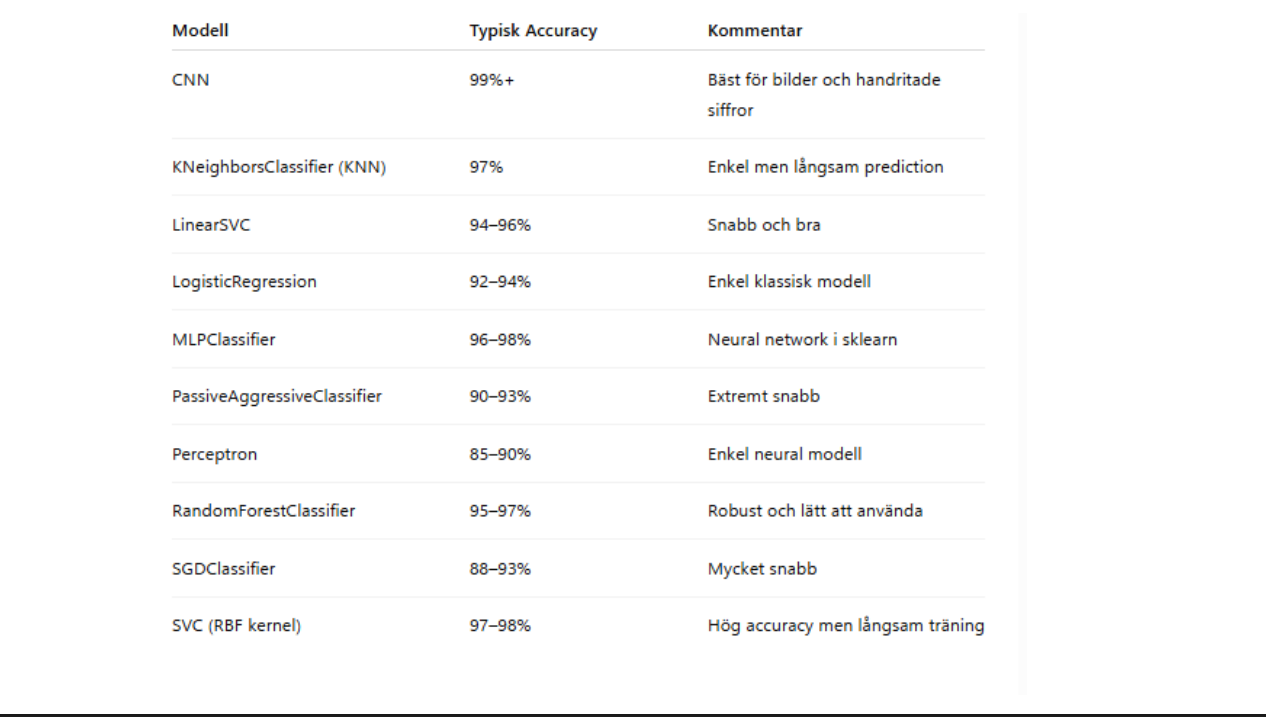

# 6. Träna modellen

In [47]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Testar modellen

In [48]:
y_pred = model.predict(X_test)

for i in range(10):
    print(f"Predicted: {y_pred[i]}  Actual: {y_test[i]}")

Predicted: 4  Actual: 4
Predicted: 0  Actual: 0
Predicted: 4  Actual: 4
Predicted: 3  Actual: 3
Predicted: 6  Actual: 6
Predicted: 4  Actual: 4
Predicted: 5  Actual: 5
Predicted: 5  Actual: 5
Predicted: 9  Actual: 9
Predicted: 9  Actual: 9


# 7. Utvärdera modellen
- accuracy
- precision
- recall
- F1-score
- loss

LogReg
Accuracy: 0.9259


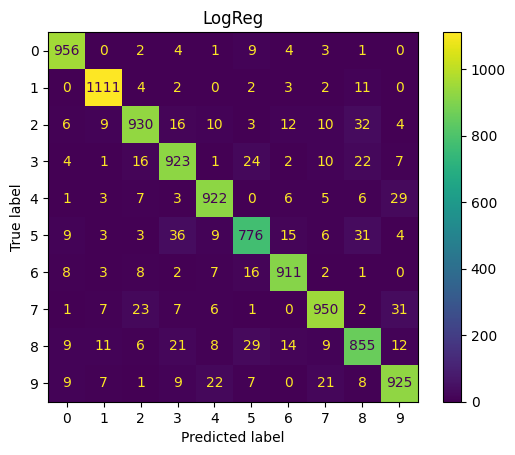

SVM
Accuracy: 0.9792


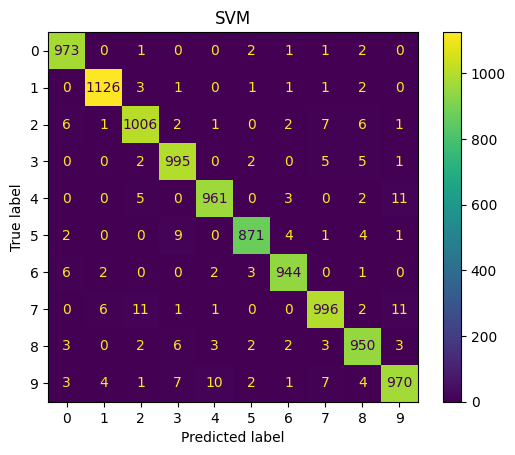

RF
Accuracy: 0.968


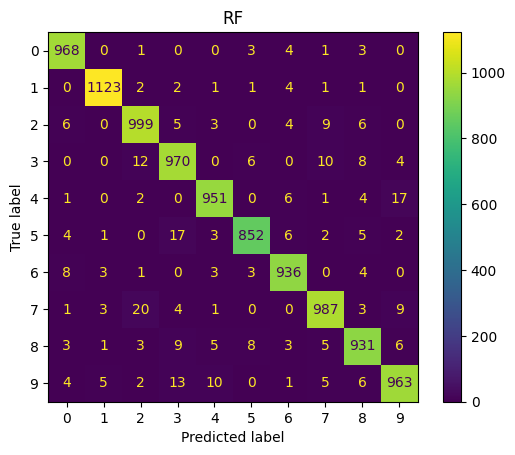

In [58]:
# Utvärdering flera modeller
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import *

# Modeller
logreg = LogisticRegression(max_iter=300)

svm = SVC()

rf = RandomForestClassifier()

# Träning
logreg.fit(X_train_mnist, y_train_mnist)
svm.fit(X_train_mnist, y_train_mnist)
rf.fit(X_train_mnist, y_train_mnist)

# Samling
models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}

# Utvärdering
for name, model in models.items():

    y_pred = model.predict(X_test_mnist)

    print(name)
    print("Accuracy:", accuracy_score(y_test_mnist, y_pred))

    ConfusionMatrixDisplay(
        confusion_matrix(y_test_mnist, y_pred)
    ).plot()

    plt.title(name)

    plt.show()

### Förbättra resultatet?

Vad kan man göra för att förbättra prestationsförmågan?
- Ompröva modellval
- Mer data. 
- Bättre kvalitet.
- Bättre Modell 
- Optimering av modellen.

In [61]:
from sklearn.metrics import classification_report

models = {
    "LogReg": logreg,
    "SVM": svm,
    "RF": rf
}

for name, model in models.items():

    y_pred = model.predict(X_test_mnist)

    print("\n", name)

    print(classification_report(y_test_mnist, y_pred))


 LogReg
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000


 SVM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
         

In [64]:
print("Training:", X_train_mnist.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_mnist.shape)

Training: (60000, 784)
Validation: (12023, 784)
Test: (10000, 784)


In [66]:

pred_labels = model.predict(X_test_mnist)

wrong = np.where(pred_labels != y_test_mnist)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 320


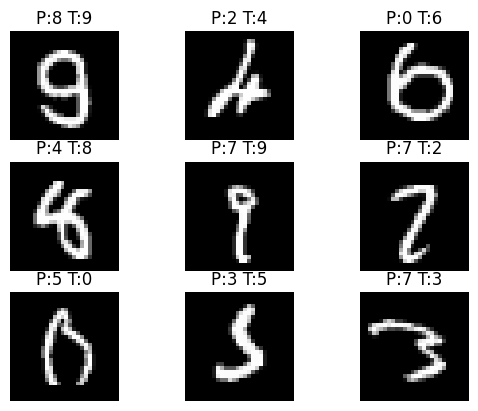

In [70]:
import matplotlib.pyplot as plt

for i in range(9):
    idx = wrong[i]
    
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test_mnist[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{pred_labels[idx]} T:{y_test_mnist[idx]}")
    plt.axis('off')

plt.show()

In [72]:
#pred_labels = np.argmax(pred, axis=1)

errors = np.where(pred_labels != y_test_mnist)[0]

# count errors per digit
counts = {i: 0 for i in range(10)}

for i in errors:
    counts[y_test_mnist[i]] += 1

print("Errors per digit:", counts)

# worst digit
worst_digit = max(counts, key=counts.get)
print("Worst digit:", worst_digit)

Errors per digit: {0: 12, 1: 12, 2: 33, 3: 40, 4: 31, 5: 40, 6: 22, 7: 41, 8: 43, 9: 46}
Worst digit: 9


# 8. Tuning / Förbättring
- hyperparametrar
- antal lager
- learning rate
- batch size
- optimizer

Gridsearch hittar bästa hyperparametrar för modellen.

### Logistic Regression - förbättringsmöjligheter
### SVM Support Vector Machine. ( MYCKET TIDSKRÄVANDE för MNIST! )
### Random Forest


In [79]:
#Logistic Regression - förbättringsmöjligheter

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.9194


In [81]:
# SVM Support Vector MAchine. MYCKET TIDSKRÄVANDE!

from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.9802


In [82]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=3
)

grid.fit(X_train_mnist, y_train_mnist)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 20, 'n_estimators': 100}
0.9640833333333333


# MLP och CNN För bilddata

## MLP Dense Neural Network tabelldata, kunddata

## CNN (Convolutional Neural Network) - Bilder och former

### CNN exempel

In [83]:
#pip install streamlit streamlit-drawable-canvas tensorflow pillow numpy matplotlib

#train_cnn.py
#python Göran_ML_CNN_model.py

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Data augmentation
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# Ladda MNIST
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# -----------------------------
# Normalisera
# -----------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# -----------------------------
# CNN behöver kanal-dimension
# (28,28) -> (28,28,1)
# -----------------------------
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# -----------------------------
# Bygg CNN
# -----------------------------
model = models.Sequential([

#    layers.Conv2D(
#        32,
#        (3, 3),
#        activation="relu",
#        input_shape=(28, 28, 1)
#    ),
   
    layers.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),

    layers.MaxPooling2D((2, 2)),

#    layers.Conv2D(
#        64,
#        (3, 3),
#        activation="relu"

    layers.Conv2D(64, (3,3), activation="relu"),              

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation="softmax"
    )
])

# -----------------------------
# Kompilera
# -----------------------------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# Träna
# -----------------------------
model.fit(
    X_train,
    y_train,
    epochs=10,
    #epochs=10,
    batch_size=64,
    validation_split=0.1
)

# -----------------------------
# Utvärdera
# -----------------------------
loss, acc = model.evaluate(X_test, y_test)

print(f"Accuracy: {acc:.4f}")


# -----------------------------
# Spara accuracy till fil
# -----------------------------
with open("accuracy.txt", "w") as f:
    f.write(f"{acc:.4f}")

print("Modell och accuracy sparad.")

# -----------------------------
# Spara modellen
# -----------------------------
model.save("mnist_cnn.keras")

print("CNN-modell sparad.")



Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9386 - loss: 0.1994 - val_accuracy: 0.9860 - val_loss: 0.0483
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9816 - loss: 0.0620 - val_accuracy: 0.9882 - val_loss: 0.0413
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0437 - val_accuracy: 0.9882 - val_loss: 0.0379
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9907 - val_loss: 0.0316
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9911 - loss: 0.0279 - val_accuracy: 0.9910 - val_loss: 0.0356
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9918 - val_loss: 0.0305
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9935 - loss: 0.0206 - val_accuracy: 0.9910 - val_loss: 0.0302
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.

In [86]:
#Evaluate accuracy
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print("Train accuracy:", train_acc)
print("Train loss:", train_loss)
print()
# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


Train accuracy: 0.9983166456222534
Train loss: 0.006384418345987797

Test accuracy: 0.9919999837875366
Test loss: 0.025174414739012718


### APP för prediktering av ritade bilder.

https://mnist-cnn-app-bappbydwvbjjfcrt63rted4.streamlit.app/

######################################################################

Test med olika optimerare.

######################################################################

In [87]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


Training with sgd
sgd - Epoch 1: 86.37%
sgd - Epoch 2: 89.20%
sgd - Epoch 3: 90.15%
sgd - Epoch 4: 90.76%
sgd - Epoch 5: 91.34%

Training with momentum
momentum - Epoch 1: 92.67%
momentum - Epoch 2: 94.58%
momentum - Epoch 3: 95.62%
momentum - Epoch 4: 96.21%
momentum - Epoch 5: 96.63%

Training with adam
adam - Epoch 1: 94.68%
adam - Epoch 2: 96.09%
adam - Epoch 3: 96.91%
adam - Epoch 4: 97.26%
adam - Epoch 5: 97.45%

Training with adamw
adamw - Epoch 1: 94.44%
adamw - Epoch 2: 96.19%
adamw - Epoch 3: 96.80%
adamw - Epoch 4: 97.11%
adamw - Epoch 5: 97.51%


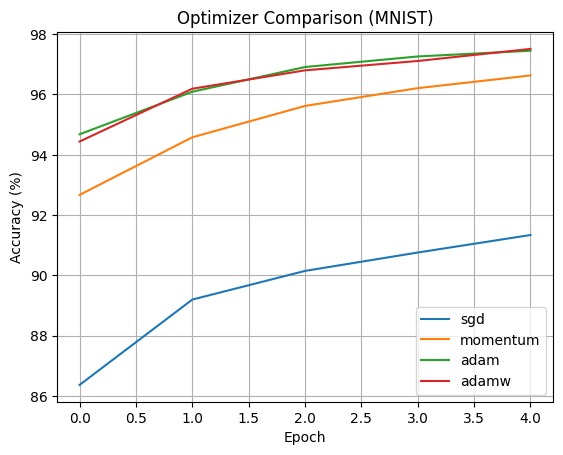

In [89]:
# ===== Data =====
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ===== Modell (MLP) =====
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# ===== Träning =====
def train_model(optimizer_name, epochs=5):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    acc_list = []

    for epoch in range(epochs):
        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ===== Test accuracy =====
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        acc_list.append(accuracy)

        print(f"{optimizer_name} - Epoch {epoch+1}: {accuracy:.2f}%")

    return acc_list

# ===== Kör alla optimerare =====
optimizers = ["sgd", "momentum", "adam", "adamw"]
results = {}

for opt in optimizers:
    print(f"\nTraining with {opt}")
    results[opt] = train_model(opt, epochs=5)

# ===== Plot =====
plt.figure()

for opt in optimizers:
    plt.plot(results[opt], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Optimizer Comparison (MNIST)")
plt.legend()
plt.grid()

plt.show()

# 9. Deployment
- webbtjänst
- mobilapp
- självkörande bil
- chatbot

CNN o MLP jämförelse
https://mnist-mlp-cnn-pwlmsb88agkgo6yxc2lugj.streamlit.app/

CNN rita siffra och prediktera
https://mnist-cnn-app-bappbydwvbjjfcrt63rted4.streamlit.app/

# 10. Övervakning
fungerar den fortfarande bra?
har datan förändrats?
behövs omträning?

APPARNA är statiska eftersom modellerna är tränade i förväg och nedsparad på hemmakatalogen.
Avvägning mellan aktuellt innehåll och mycket långsam laddning eller snabb start med sparad modell.

######################################################################